# UNIT IV: RANDOM NUMBER

## Simulation Scenario: Student Selection for Health Survey

A college has 100 students.

The administration wants to randomly select students for a health and weight survey.

In simulation, random numbers help us select students fairly without bias.

This notebook explains:

. Random number properties
. Pseudo-random numbers
. Mid-square method
. Residue method
. Uniformity test
. Chi-square test
. Autocorrelation test


In [2]:



# =====================================================
# STEP 1: Import Required Libraries
# =====================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2








# Step 1: Create Student Dataset

We assume 100 students.

Each student has:

. Student ID
. Student name
. Weight
. Random number
. Selection status

This dataset is used to understand random number simulation.





In [3]:

# =====================================================
# STEP 2: Create Dataset of 100 Students
# =====================================================

n = 100

students = pd.DataFrame({
    "Student_ID": np.arange(1, n + 1),
    "Student_Name": [f"Student_{i}" for i in range(1, n + 1)],
    "Weight_kg": np.random.randint(40, 80, n)
})

students.head()




,Student_ID,Student_Name,Weight_kg
0,1,Student_1,78
1,2,Student_2,68
2,3,Student_3,54
3,4,Student_4,47
4,5,Student_5,60


In [5]:
students

,Student_ID,Student_Name,Weight_kg
0,1,Student_1,78
1,2,Student_2,68
2,3,Student_3,54
3,4,Student_4,47
4,5,Student_5,60
...,...,...,...
95,96,Student_96,48
96,97,Student_97,47
97,98,Student_98,51
98,99,Student_99,73




---



---



---



---



---



---



---



---



# 4.1 Random Number Properties and Tables

Random numbers should have two important properties:

. Uniformity
. Independence

## Uniformity

Uniformity means numbers should be evenly distributed between 0 and 1.

## Independence

Independence means one random number should not depend on another random number.

In simulation, random numbers help represent uncertain events.

Examples:

. Student selection
. Customer arrival
. Service time
. Traffic movement
. Machine failure

In [6]:




# =====================================================
# STEP 3: Generate Random Numbers
# =====================================================

students["Random_Number"] = np.random.random(n)

students.head()





,Student_ID,Student_Name,Weight_kg,Random_Number
0,1,Student_1,78,0.063558
1,2,Student_2,68,0.310982
2,3,Student_3,54,0.325183
3,4,Student_4,47,0.729606
4,5,Student_5,60,0.637557


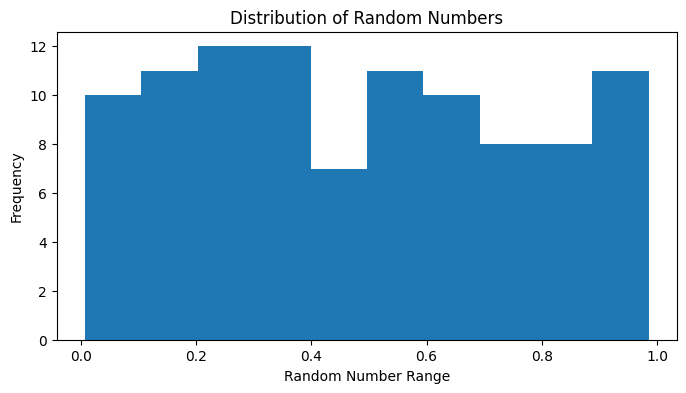

In [7]:


# =====================================================
# STEP 4: Visualize Random Numbers
# =====================================================

plt.figure(figsize=(8, 4))
plt.hist(students["Random_Number"], bins=10)
plt.title("Distribution of Random Numbers")
plt.xlabel("Random Number Range")
plt.ylabel("Frequency")
plt.show()





# Interpretation

The histogram shows how random numbers are distributed between 0 and 1.

If all bars are nearly equal, the random numbers are approximately uniform.

If some bars are very high and some are very low, the numbers may not be uniform.





---



---



---



---




# 4.2 Pseudo-Random Numbers

Pseudo-random numbers are generated by computer algorithms.

They look random, but they are created using mathematical logic.



---



In Python:

np.random.random()

generates pseudo-random numbers.

Pseudo-random numbers are useful because:

. They are fast
. They are easy to generate
. They can be repeated using seed value
. They are useful in simulation


In [8]:

# =====================================================
# STEP 5: Select Students Using Pseudo-Random Numbers
# =====================================================

# Select students whose random number is less than 0.15
students["Selected"] = students["Random_Number"] < 0.15

selected_students = students[students["Selected"] == True]

selected_students.head()




,Student_ID,Student_Name,Weight_kg,Random_Number,Selected
0,1,Student_1,78,0.063558,True
7,8,Student_8,62,0.119594,True
15,16,Student_16,61,0.025419,True
16,17,Student_17,41,0.107891,True
17,18,Student_18,63,0.031429,True


In [9]:




# =====================================================
# STEP 6: Selected Student Summary
# =====================================================

print("Total selected students:", selected_students.shape[0])
print("Average weight of selected students:", selected_students["Weight_kg"].mean())





Total selected students: 17
Average weight of selected students: 58.11764705882353



# Interpretation

Students are selected using random numbers.

If Random_Number < 0.15, the student is selected.

This simulates random sampling.

The selected students can be used for health survey analysis.


# 4.3 Random Number Generation Method 1: Mid-Square Method

Mid-square method is an early random number generation method.

Steps:

. Choose a seed number
. Square the seed
. Take middle digits
. Use middle digits as next seed
. Convert into random number
. Repeat the process

Example:

Seed = 5735

5735² = 32890225

Middle 4 digits = 8902

Random number = 0.8902


In [10]:




# =====================================================
# STEP 7: Mid-Square Method Function
# =====================================================

def mid_square(seed, digits=4, count=10):
    numbers = []
    current = seed

    for _ in range(count):
        square = current ** 2
        square_str = str(square).zfill(digits * 2)

        start = (len(square_str) - digits) // 2
        middle = square_str[start:start + digits]

        current = int(middle)
        random_number = current / (10 ** digits)
        numbers.append(random_number)

    return numbers

mid_square_numbers = mid_square(seed=5735, digits=4, count=10)

mid_square_numbers






[0.8902,
 0.2456,
 0.0319,
 0.1017,
 0.0342,
 0.1169,
 0.3665,
 0.4322,
 0.6796,
 0.1856]

In [11]:

# =====================================================
# STEP 8: Mid-Square Result Table
# =====================================================

mid_df = pd.DataFrame({
    "Iteration": range(1, 11),
    "Random_Number": mid_square_numbers
})

mid_df




,Iteration,Random_Number
0,1,0.8902
1,2,0.2456
2,3,0.0319
3,4,0.1017
4,5,0.0342
5,6,0.1169
6,7,0.3665
7,8,0.4322
8,9,0.6796
9,10,0.1856


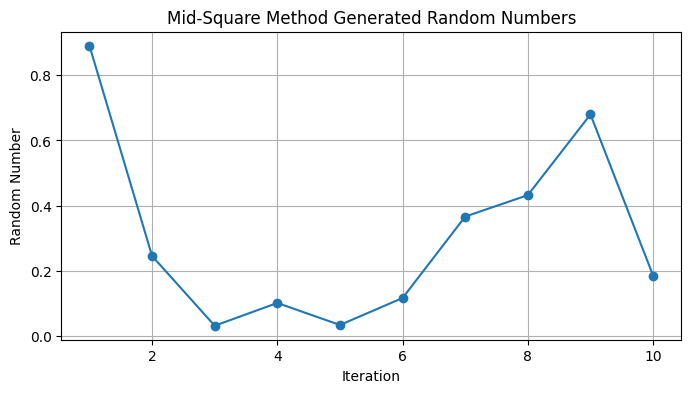

In [12]:




# =====================================================
# STEP 9: Visualize Mid-Square Random Numbers
# =====================================================

plt.figure(figsize=(8, 4))
plt.plot(mid_df["Iteration"], mid_df["Random_Number"], marker="o")
plt.title("Mid-Square Method Generated Random Numbers")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
plt.grid(True)
plt.show()







# Interpretation

The mid-square method generates random numbers using a seed.

Advantages:

. Easy to understand
. Simple calculation
. Useful for teaching purpose

Disadvantages:

. May repeat quickly
. May become zero
. Poor randomness
. Not suitable for large practical simulation






# 4.3 Random Number Generation Method 2: Residue Method

Residue method is also called Linear Congruential Method.

Formula:

X(n+1) = (aXn + c) mod m

Where:

. Xn = current seed
. X(n+1) = next generated number
. a = multiplier
. c = increment
. m = modulus

Random number:

Rn = Xn / m

In [13]:


# =====================================================
# STEP 10: Residue Method / Linear Congruential Method
# =====================================================

def residue_method(seed, a, c, m, count=10):
    numbers = []
    x_values = []
    x = seed

    for _ in range(count):
        x = (a * x + c) % m
        r = x / m
        x_values.append(x)
        numbers.append(r)

    return x_values, numbers

x_values, residue_numbers = residue_method(
    seed=7,
    a=5,
    c=3,
    m=16,
    count=10
)

residue_numbers





[0.375, 0.0625, 0.5, 0.6875, 0.625, 0.3125, 0.75, 0.9375, 0.875, 0.5625]

In [14]:



# =====================================================
# STEP 11: Residue Method Result Table
# =====================================================

residue_df = pd.DataFrame({
    "Iteration": range(1, 11),
    "X_Value": x_values,
    "Random_Number": residue_numbers
})

residue_df




,Iteration,X_Value,Random_Number
0,1,6,0.3750
1,2,1,0.0625
2,3,8,0.5000
3,4,11,0.6875
4,5,10,0.6250
5,6,5,0.3125
6,7,12,0.7500
7,8,15,0.9375
8,9,14,0.8750
9,10,9,0.5625


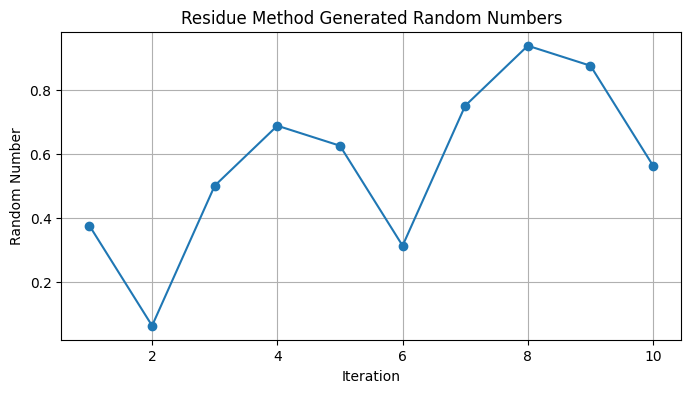

In [15]:



# =====================================================
# STEP 12: Visualize Residue Method Random Numbers
# =====================================================

plt.figure(figsize=(8, 4))
plt.plot(residue_df["Iteration"], residue_df["Random_Number"], marker="o")
plt.title("Residue Method Generated Random Numbers")
plt.xlabel("Iteration")
plt.ylabel("Random Number")
plt.grid(True)
plt.show()





# Interpretation

Residue method is better than mid-square method.

But quality depends on:

. seed
. multiplier
. increment
. modulus

If parameters are poor, the sequence may repeat quickly.

If parameters are good, it can generate better pseudo-random numbers.



# 4.4 Testing Numbers for Randomness

After generating random numbers, we must test their quality.

Two important tests are:

. Uniformity test
. Chi-square test


---


Uniformity test checks whether numbers are evenly distributed.

Chi-square test statistically checks whether observed frequency and expected frequency are close.


In [16]:

# =====================================================
# STEP 13: Uniformity Test using Frequency Table
# =====================================================

random_numbers = students["Random_Number"]

observed, bins = np.histogram(random_numbers, bins=10, range=(0, 1))

uniformity_table = pd.DataFrame({
    "Interval": [f"{round(bins[i],1)} - {round(bins[i+1],1)}" for i in range(len(bins)-1)],
    "Observed_Frequency": observed
})

uniformity_table

,Interval,Observed_Frequency
0,0.0 - 0.1,10
1,0.1 - 0.2,11
2,0.2 - 0.3,12
3,0.3 - 0.4,12
4,0.4 - 0.5,8
5,0.5 - 0.6,10
6,0.6 - 0.7,10
7,0.7 - 0.8,8
8,0.8 - 0.9,10
9,0.9 - 1.0,9


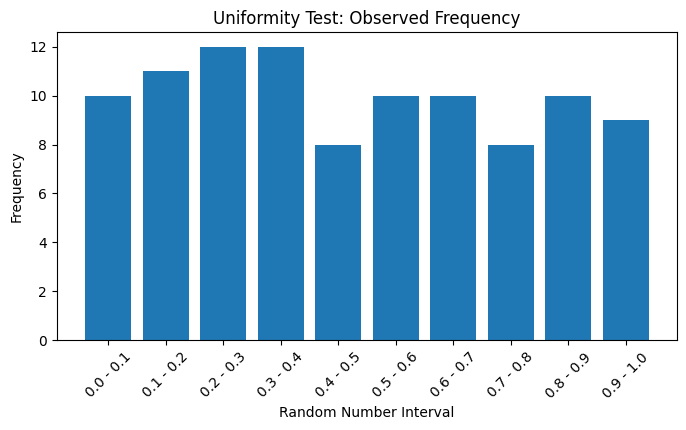

In [17]:

# =====================================================
# STEP 14: Uniformity Visualization
# =====================================================

plt.figure(figsize=(8, 4))
plt.bar(uniformity_table["Interval"], uniformity_table["Observed_Frequency"])
plt.title("Uniformity Test: Observed Frequency")
plt.xlabel("Random Number Interval")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


# Interpretation

For 100 numbers and 10 intervals:

Expected frequency = 100 / 10 = 10

If observed frequencies are close to 10, the numbers are approximately uniform.


In [18]:

# =====================================================
# STEP 15: Chi-Square Test
# =====================================================

N = len(random_numbers)
k = 10
expected = N / k

chi_square_values = ((observed - expected) ** 2) / expected
chi_square_calculated = chi_square_values.sum()

df_chi = k - 1
alpha = 0.05
chi_square_critical = chi2.ppf(1 - alpha, df_chi)

chi_table = pd.DataFrame({
    "Interval": uniformity_table["Interval"],
    "Observed": observed,
    "Expected": expected,
    "(O-E)^2/E": chi_square_values
})

chi_table


,Interval,Observed,Expected,(O-E)^2/E
0,0.0 - 0.1,10,10.0,0.0
1,0.1 - 0.2,11,10.0,0.1
2,0.2 - 0.3,12,10.0,0.4
3,0.3 - 0.4,12,10.0,0.4
4,0.4 - 0.5,8,10.0,0.4
5,0.5 - 0.6,10,10.0,0.0
6,0.6 - 0.7,10,10.0,0.0
7,0.7 - 0.8,8,10.0,0.4
8,0.8 - 0.9,10,10.0,0.0
9,0.9 - 1.0,9,10.0,0.1


In [19]:





# =====================================================
# STEP 16: Chi-Square Decision
# =====================================================

print("Chi-square calculated:", chi_square_calculated)
print("Chi-square critical:", chi_square_critical)
print("Degree of freedom:", df_chi)

if chi_square_calculated < chi_square_critical:
    print("Decision: Accept H0")
    print("Conclusion: Random numbers are uniformly distributed.")
else:
    print("Decision: Reject H0")
    print("Conclusion: Random numbers are not uniformly distributed.")







Chi-square calculated: 1.8000000000000003
Chi-square critical: 16.918977604620448
Degree of freedom: 9
Decision: Accept H0
Conclusion: Random numbers are uniformly distributed.



# Chi-Square Test Interpretation

Hypothesis:

H0: Random numbers are uniformly distributed.
H1: Random numbers are not uniformly distributed.

Decision rule:

If chi-square calculated < chi-square critical:

. Accept H0
. Numbers are uniformly distributed

If chi-square calculated > chi-square critical:

. Reject H0
. Numbers are not uniformly distributed




# 4.5 Testing for Autocorrelation

Autocorrelation checks whether random numbers are independent.

If one random number depends on the previous random number, autocorrelation exists.

Good random numbers should have low autocorrelation.

Autocorrelation close to 0 means:

. Numbers are independent
. No strong pattern exists


In [20]:



# =====================================================
# STEP 17: Autocorrelation Test
# =====================================================

def autocorrelation_test(numbers, lag=1):
    x = np.array(numbers)
    x1 = x[:-lag]
    x2 = x[lag:]
    correlation = np.corrcoef(x1, x2)[0, 1]
    return correlation

lag_1_corr = autocorrelation_test(random_numbers, lag=1)
lag_2_corr = autocorrelation_test(random_numbers, lag=2)
lag_5_corr = autocorrelation_test(random_numbers, lag=5)

print("Autocorrelation with lag 1:", lag_1_corr)
print("Autocorrelation with lag 2:", lag_2_corr)
print("Autocorrelation with lag 5:", lag_5_corr)





Autocorrelation with lag 1: -0.004063320179912268
Autocorrelation with lag 2: -0.040849249606101826
Autocorrelation with lag 5: -0.15819824773519467


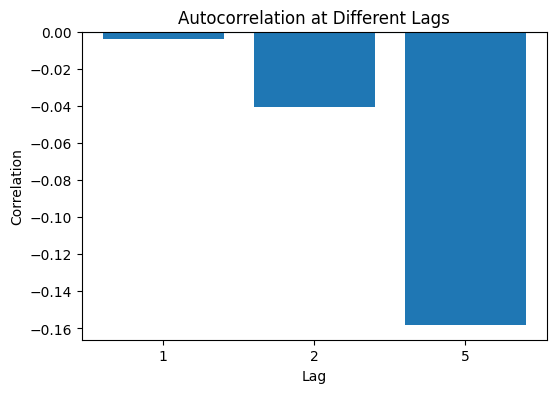

In [21]:



# =====================================================
# STEP 18: Visualize Autocorrelation
# =====================================================

lags = [1, 2, 5]
corr_values = [lag_1_corr, lag_2_corr, lag_5_corr]

plt.figure(figsize=(6, 4))
plt.bar([str(lag) for lag in lags], corr_values)
plt.title("Autocorrelation at Different Lags")
plt.xlabel("Lag")
plt.ylabel("Correlation")
plt.axhline(0)
plt.show()





# Interpretation

Autocorrelation close to 0 means random numbers are independent.

If autocorrelation is highly positive or highly negative, the numbers may be dependent.

For good random numbers:

. Correlation should be near 0
. No strong pattern should exist
. Values should not follow predictable sequence


In [22]:

# =====================================================
# STEP 19: View Final Student Dataset
# =====================================================

students.head(20)


,Student_ID,Student_Name,Weight_kg,Random_Number,Selected
0,1,Student_1,78,0.063558,True
1,2,Student_2,68,0.310982,False
2,3,Student_3,54,0.325183,False
3,4,Student_4,47,0.729606,False
4,5,Student_5,60,0.637557,False
5,6,Student_6,78,0.887213,False
6,7,Student_7,58,0.472215,False
7,8,Student_8,62,0.119594,True
8,9,Student_9,50,0.713245,False
9,10,Student_10,50,0.760785,False


In [23]:


# =====================================================
# STEP 20: Save Dataset as CSV
# =====================================================

students.to_csv("student_random_number_simulation_dataset.csv", index=False)

print("Dataset saved as student_random_number_simulation_dataset.csv")





Dataset saved as student_random_number_simulation_dataset.csv
